# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

**Curso:** ISIS2611  
**Nombres:** 
- Angel Felipe Restrepo Castillo — 201914073
- Laura Valentina Jimenez Tovar — 201924116

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, validation_curve, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures, StandardScaler

## 1. Carga y preparación mínima de los datos

Cargamos las librerías necesarias y los datos limpios del Laboratorio 1.

In [2]:
ruta_entrenamiento = './data/Datos Lab 1.csv'
ruta_test_externo = './data/Datos Test Lab 1.csv'

data = pd.read_csv(ruta_entrenamiento).copy()
data_test_externo = pd.read_csv(ruta_test_externo).copy()

print('Datos etiquetados:', data.shape)
print('Datos test externos:', data_test_externo.shape)

Datos etiquetados: (2576, 27)
Datos test externos: (364, 27)


In [3]:
# Variable objetivo
target = 'temp_max_manana'

# Eliminar duplicados antes de dividir los datos
data = data.drop_duplicates().copy()

# Solo se conservan registros con objetivo conocido para el modelado supervisado
data_modelo = data[data[target].notna()].copy()

X = data_modelo.drop(columns=[target])
y = data_modelo[target]

print('Datos etiquetados después de limpieza:', data_modelo.shape)
print('X:', X.shape)
print('y:', y.shape)

Datos etiquetados después de limpieza: (2477, 27)
X: (2477, 26)
y: (2477,)


In [4]:
# Variables utilizadas en los pipelines
numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio', 'dia_del_anio'
]

categorical_features = ['estacion_anio', 'mes', 'sector_viento']

# Variables auxiliares para reproducibilidad
RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# El test se separa antes de cualquier GridSearchCV.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print('Entrenamiento:', X_train.shape)
print('Test:', X_test.shape)

Entrenamiento: (1857, 26)
Test: (620, 26)


El 25% de los datos etiquetados se reserva como test y permanece fuera de toda búsqueda de hiperparámetros. El 75% restante se utiliza para entrenamiento y validación cruzada. Así se evita usar información del conjunto de test para escoger grado, escalamiento o penalización.

# 2. Construcción del modelo de regresión polinomial

El pipeline aplica imputación y escalamiento a las variables numéricas, luego genera características polinomiales. Las variables categóricas se imputan y codifican mediante One-Hot Encoding. `GridSearchCV` explora simultáneamente el grado del polinomio y el escalamiento. Se utilizan RMSE, MAE y R² como métricas de evaluación.

In [5]:
def construir_preprocesador_polynomial():
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ], remainder='drop')

pipeline_polinomial = Pipeline([
    ('preprocesamiento', construir_preprocesador_polynomial()),
    ('modelo', LinearRegression())
])

scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

param_grid_polinomial = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]
}

grid_polinomial = GridSearchCV(
    pipeline_polinomial,
    param_grid=param_grid_polinomial,
    scoring=scoring,
    refit='RMSE',
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

grid_polinomial.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_polinomial.best_params_)
print(f"RMSE CV: {-grid_polinomial.best_score_:.4f}")

Mejores hiperparámetros: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
RMSE CV: 19.7094


In [6]:
# Tabla completa de las combinaciones del modelo polinomial
cv_poly = pd.DataFrame(grid_polinomial.cv_results_).copy()
cv_poly['RMSE_train'] = -cv_poly['mean_train_RMSE']
cv_poly['RMSE_CV'] = -cv_poly['mean_test_RMSE']
cv_poly['MAE_CV'] = -cv_poly['mean_test_MAE']
cv_poly['Std_RMSE_CV'] = cv_poly['std_test_RMSE']
cv_poly['R2_CV'] = cv_poly['mean_test_R2']

resultados_polinomial = cv_poly[[
    'param_preprocesamiento__num__polynomial__degree',
    'param_preprocesamiento__num__scaler',
    'RMSE_train', 'RMSE_CV', 'Std_RMSE_CV', 'MAE_CV', 'R2_CV'
]].sort_values('RMSE_CV')

resultados_polinomial

,param_preprocesamiento__num__polynomial__degree,param_preprocesamiento__num__scaler,RMSE_train,RMSE_CV,Std_RMSE_CV,MAE_CV,R2_CV
0,1,StandardScaler(),6.369148,1.970940e+01,2.461890e+01,6.201344e+00,-1.100646e+01
1,1,MinMaxScaler(),6.369149,1.971070e+01,2.462099e+01,6.201468e+00,-1.100832e+01
2,2,StandardScaler(),4.084719,5.739498e+04,1.145883e+05,2.985314e+03,-1.985254e+08
3,2,MinMaxScaler(),4.084719,5.810119e+04,1.142405e+05,3.026087e+03,-1.985504e+08
5,3,MinMaxScaler(),0.008941,4.376530e+08,8.753011e+08,2.272199e+07,-1.157566e+16
4,3,StandardScaler(),0.008941,6.104818e+08,1.220957e+09,3.169480e+07,-2.252329e+16


Los resultados muestran que el grado 1 presenta el mejor desempeño de validación, con un RMSE de aproximadamente 19.71. Al aumentar el grado a 2, el RMSE de validación aumenta drásticamente hasta aproximadamente 57 395, mientras que para grado 3 alcanza valores del orden de cientos de millones.

Aunque el RMSE de entrenamiento disminuye al aumentar el grado, el error de validación aumenta considerablemente. Esto indica que el incremento de complejidad permite ajustar mejor los datos de entrenamiento, pero perjudica la capacidad de generalización. Por tanto, los grados 2 y 3 presentan un comportamiento de sobreajuste.

# 3. Curvas de validación

Para aislar el efecto de la complejidad, se fija el escalamiento seleccionado por la búsqueda polinomial y se varía únicamente el grado. Se muestran la media y una desviación estándar de RMSE para entrenamiento y validación.

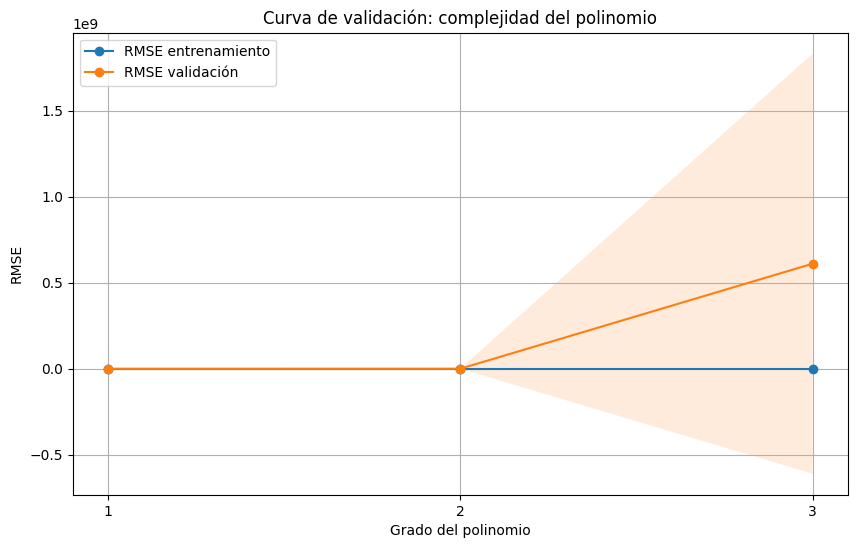

,Grado,RMSE_train_mean,RMSE_train_std,RMSE_validacion_mean,RMSE_validacion_std
0,1,6.369148,0.094494,1.970940e+01,2.461890e+01
1,2,4.084719,0.179435,5.739498e+04,1.145883e+05
2,3,0.008941,0.007301,6.104818e+08,1.220957e+09


In [7]:
mejor_scaler_poly = grid_polinomial.best_params_['preprocesamiento__num__scaler']
grados = np.array([1, 2, 3])

pipeline_curva = Pipeline([
    ('preprocesamiento', construir_preprocesador_polynomial()),
    ('modelo', LinearRegression())
])

train_scores_curve, val_scores_curve = validation_curve(
    pipeline_curva,
    X_train,
    y_train,
    param_name='preprocesamiento__num__polynomial__degree',
    param_range=grados,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# La curva debe usar el escalamiento seleccionado para hacer comparable el análisis.
pipeline_curva.set_params(preprocesamiento__num__scaler=mejor_scaler_poly)
train_scores_curve, val_scores_curve = validation_curve(
    pipeline_curva,
    X_train,
    y_train,
    param_name='preprocesamiento__num__polynomial__degree',
    param_range=grados,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_train_mean = -train_scores_curve.mean(axis=1)
rmse_train_std = train_scores_curve.std(axis=1)
rmse_val_mean = -val_scores_curve.mean(axis=1)
rmse_val_std = val_scores_curve.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(grados, rmse_train_mean, marker='o', label='RMSE entrenamiento')
plt.fill_between(grados, rmse_train_mean-rmse_train_std, rmse_train_mean+rmse_train_std, alpha=0.15)
plt.plot(grados, rmse_val_mean, marker='o', label='RMSE validación')
plt.fill_between(grados, rmse_val_mean-rmse_val_std, rmse_val_mean+rmse_val_std, alpha=0.15)
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validación: complejidad del polinomio')
plt.xticks(grados)
plt.legend()
plt.grid(True)
plt.show()

curva_validacion = pd.DataFrame({
    'Grado': grados,
    'RMSE_train_mean': rmse_train_mean,
    'RMSE_train_std': rmse_train_std,
    'RMSE_validacion_mean': rmse_val_mean,
    'RMSE_validacion_std': rmse_val_std
})
curva_validacion

Se utiliza una curva de validación para analizar cómo cambia el RMSE promedio de entrenamiento y validación a medida que aumenta el grado del polinomio. La banda alrededor de cada curva representa ±1 desviación estándar entre los folds de validación cruzada.

El grado 1 presenta el menor error promedio de validación. Al pasar a grado 2 y grado 3, el error de entrenamiento continúa disminuyendo, pero el error de validación aumenta de manera muy pronunciada. Además, la amplitud de la banda de desviación estándar crece considerablemente, lo que evidencia una mayor variabilidad del desempeño entre las particiones.

Desde la perspectiva del trade-off sesgo-varianza, aumentar la complejidad reduce el sesgo del modelo al permitir un ajuste más flexible, pero incrementa fuertemente la varianza. En este caso, el aumento de la varianza domina y produce sobreajuste a partir del grado 2. Por esta razón, una mayor complejidad polinomial no resulta conveniente para estos datos.

# 4. Modelos de regresión lineal regularizados: Ridge y Lasso

Se usan pipelines separados con escalamiento y regularización dentro de la búsqueda. `alpha` es un hiperparámetro y se comparan StandardScaler y MinMaxScaler.

In [8]:
def construir_preprocesador_lineal():
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ], remainder='drop')

pipeline_ridge = Pipeline([
    ('preprocesamiento', construir_preprocesador_lineal()),
    ('modelo', Ridge())
])

pipeline_lasso = Pipeline([
    ('preprocesamiento', construir_preprocesador_lineal()),
    ('modelo', Lasso(max_iter=100000))
])

alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
alphas_lasso = [0.001, 0.01, 0.1, 1, 10, 100]
scalers = [StandardScaler(), MinMaxScaler()]

param_grid_ridge = {
    'modelo__alpha': alphas_ridge,
    'preprocesamiento__num__scaler': scalers
}

param_grid_lasso = {
    'modelo__alpha': alphas_lasso,
    'preprocesamiento__num__scaler': scalers
}

grid_ridge = GridSearchCV(
    pipeline_ridge, param_grid_ridge, scoring=scoring,
    refit='RMSE', cv=cv, return_train_score=True, n_jobs=-1
)
grid_lasso = GridSearchCV(
    pipeline_lasso, param_grid_lasso, scoring=scoring,
    refit='RMSE', cv=cv, return_train_score=True, n_jobs=-1
)

grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)

print('Ridge:', grid_ridge.best_params_, f"RMSE CV = {-grid_ridge.best_score_:.4f}")
print('Lasso:', grid_lasso.best_params_, f"RMSE CV = {-grid_lasso.best_score_:.4f}")

Ridge: {'modelo__alpha': 1000, 'preprocesamiento__num__scaler': MinMaxScaler()} RMSE CV = 8.9687
Lasso: {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()} RMSE CV = 7.0487



Ridge obtiene su mejor desempeño con α = 1000 y MinMaxScaler, alcanzando un RMSE promedio de validación de 8.9687, un MAE de 7.2052 y un R² de 0.0466. 

Lasso obtiene un mejor resultado con α = 0.1 y MinMaxScaler, alcanzando un RMSE promedio de validación de 7.0487, un MAE de 5.4494 y un R² de 0.4123. Además, su desviación estándar del RMSE es 0.4361, lo que indica un desempeño estable entre los folds.

En comparación con la regresión sin regularización, ambos métodos regularizados reducen considerablemente el error de validación. Lasso presenta el mejor equilibrio entre precisión y estabilidad.

In [9]:
def resumir_grid(grid):
    r = pd.DataFrame(grid.cv_results_).copy()
    r['RMSE_train'] = -r['mean_train_RMSE']
    r['RMSE_CV'] = -r['mean_test_RMSE']
    r['MAE_CV'] = -r['mean_test_MAE']
    r['Std_RMSE_CV'] = r['std_test_RMSE']
    r['R2_CV'] = r['mean_test_R2']
    return r

resultados_ridge_grid = resumir_grid(grid_ridge)
resultados_lasso_grid = resumir_grid(grid_lasso)

print('Ridge')
display(resultados_ridge_grid[[
    'param_modelo__alpha', 'param_preprocesamiento__num__scaler',
    'RMSE_train', 'RMSE_CV', 'Std_RMSE_CV', 'MAE_CV', 'R2_CV'
]].sort_values('RMSE_CV'))

print('Lasso')
display(resultados_lasso_grid[[
    'param_modelo__alpha', 'param_preprocesamiento__num__scaler',
    'RMSE_train', 'RMSE_CV', 'Std_RMSE_CV', 'MAE_CV', 'R2_CV'
]].sort_values('RMSE_CV'))

Ridge


,param_modelo__alpha,param_preprocesamiento__num__scaler,RMSE_train,RMSE_CV,Std_RMSE_CV,MAE_CV,R2_CV
13,1000.000,MinMaxScaler(),8.790681,8.968679,0.439237,7.205198,0.046614
15,10000.000,MinMaxScaler(),9.161573,9.165736,0.363581,7.492781,0.005641
10,100.000,StandardScaler(),6.757902,10.623250,7.196068,5.605369,-0.975817
11,100.000,MinMaxScaler(),7.470671,10.738310,6.228123,6.212740,-0.846007
14,10000.000,StandardScaler(),8.650702,11.288789,5.181019,7.242281,-0.843978
12,1000.000,StandardScaler(),7.345931,14.124542,13.321899,6.256609,-3.540542
8,10.000,StandardScaler(),6.470271,15.822063,17.556027,5.828084,-5.736878
9,10.000,MinMaxScaler(),6.554664,15.835303,17.546345,5.852955,-5.737443
6,1.000,StandardScaler(),6.385471,19.107259,23.676990,6.120697,-10.173972
4,0.100,StandardScaler(),6.371220,19.659698,24.562443,6.195743,-10.949170


Lasso


,param_modelo__alpha,param_preprocesamiento__num__scaler,RMSE_train,RMSE_CV,Std_RMSE_CV,MAE_CV,R2_CV
5,0.100,MinMaxScaler(),6.994333,7.048685,0.436130,5.449408,0.412293
6,1.000,StandardScaler(),7.453359,7.460435,0.445069,5.869927,0.341855
4,0.100,StandardScaler(),6.851118,8.490762,2.930201,5.475776,0.039304
7,1.000,MinMaxScaler(),9.015784,9.021108,0.369047,7.360251,0.036811
11,100.000,MinMaxScaler(),9.213004,9.216602,0.363083,7.540502,-0.005446
10,100.000,StandardScaler(),9.213004,9.216602,0.363083,7.540502,-0.005446
9,10.000,MinMaxScaler(),9.213004,9.216602,0.363083,7.540502,-0.005446
8,10.000,StandardScaler(),9.213004,9.216602,0.363083,7.540502,-0.005446
3,0.010,MinMaxScaler(),6.517579,15.702551,17.351520,5.809280,-5.604639
2,0.010,StandardScaler(),6.474767,17.697194,21.286243,5.934682,-8.247696


In [10]:
mejor_lasso = grid_lasso.best_estimator_
modelo_lasso = mejor_lasso.named_steps['modelo']
pre_lasso = mejor_lasso.named_steps['preprocesamiento']
nombres_lasso = pre_lasso.get_feature_names_out()
coef_lasso = modelo_lasso.coef_

coeficientes_lasso = pd.DataFrame({
    'Caracteristica': nombres_lasso,
    'Coeficiente': coef_lasso,
    'Abs_coeficiente': np.abs(coef_lasso)
}).sort_values('Abs_coeficiente', ascending=False)

n_ceros = int(np.isclose(coeficientes_lasso['Coeficiente'], 0.0, atol=1e-10).sum())
n_no_ceros = len(coeficientes_lasso) - n_ceros

print('Características totales:', len(coeficientes_lasso))
print('Coeficientes llevados a cero:', n_ceros)
print('Coeficientes no nulos:', n_no_ceros)
print('\nCaracterísticas con mayor magnitud absoluta:')
display(coeficientes_lasso.head(15))

print('\nCaracterísticas llevadas a cero:')
display(coeficientes_lasso[np.isclose(coeficientes_lasso['Coeficiente'], 0.0, atol=1e-10)])

Características totales: 144
Coeficientes llevados a cero: 128
Coeficientes no nulos: 16

Características con mayor magnitud absoluta:


,Caracteristica,Coeficiente,Abs_coeficiente
7,num__humedad_desv,21.612745,21.612745
21,num__dia_del_anio,4.965585,4.965585
69,cat__mes_July,3.436104,3.436104
6,num__humedad_max,-2.771433,2.771433
58,cat__mes_December,-2.318900,2.318900
3,num__presion_desv,-2.272577,2.272577
71,cat__mes_June,2.072604,2.072604
55,cat__mes_August,2.055402,2.055402
20,num__anio,1.723819,1.723819
62,cat__mes_February,-1.706289,1.706289



Características llevadas a cero:


,Caracteristica,Coeficiente,Abs_coeficiente
15,num__rafaga_desv,-0.0,0.0
14,num__rafaga_max,0.0,0.0
13,num__rafaga_min,-0.0,0.0
12,num__rafaga_media,-0.0,0.0
11,num__viento_desv,0.0,0.0
...,...,...,...
139,cat__sector_viento_ne,0.0,0.0
140,cat__sector_viento_no,-0.0,0.0
141,cat__sector_viento_o,-0.0,0.0
142,cat__sector_viento_s,-0.0,0.0


Lasso realiza selección automática de características al llevar algunos coeficientes exactamente a cero. De las 144 características generadas mediante las variables numéricas y el One-Hot Encoding, 128 coeficientes fueron llevados a cero y 16 permanecieron diferentes de cero.

Esto implica que aproximadamente el 88.9% de los coeficientes fueron anulados por la penalización L1, reduciendo la complejidad efectiva del modelo y facilitando su interpretación. Sin embargo, un coeficiente igual a cero no implica que la variable carezca de importancia en el fenómeno, sino que, bajo la penalización seleccionada, el modelo no encuentra suficiente aporte predictivo adicional para mantenerla.

Entre las características con mayor magnitud absoluta se encuentran `num__humedad_desv`, `num__dia_del_anio`, `cat__mes_July`, `num__humedad_max` y `cat__mes_December`.

Además de observar si Lasso lleva coeficientes a cero y Ridge los reduce, se cuantifica la variabilidad de los coeficientes entre los folds de validación cruzada para los tres modelos lineales. Esto permite distinguir la estabilidad del desempeño (variación del RMSE) de la estabilidad de los parámetros del modelo.

In [11]:
# Construimos las métricas de estabilidad de coeficientes sobre los mejores pipelines.
mejores_lineales = {
    'Regresión lineal': grid_polinomial.best_estimator_,
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_
}

# Para la regresión lineal usamos el mejor pipeline del grid polinomial solo si su grado es 1.
# Si GridSearch eligiera un grado > 1, construimos explícitamente el mejor modelo lineal de grado 1.
best_degree = int(grid_polinomial.best_params_['preprocesamiento__num__polynomial__degree'])
if best_degree != 1:
    pipeline_lineal_base = Pipeline([
        ('preprocesamiento', construir_preprocesador_lineal()),
        ('modelo', LinearRegression())
    ])
    grid_lineal = GridSearchCV(
        pipeline_lineal_base,
        {'preprocesamiento__num__scaler': scalers},
        scoring=scoring, refit='RMSE', cv=cv,
        return_train_score=True, n_jobs=-1
    )
    grid_lineal.fit(X_train, y_train)
    mejores_lineales['Regresión lineal'] = grid_lineal.best_estimator_

coef_stability_rows = []
for nombre, estimator in mejores_lineales.items():
    cv_coef = cross_validate(
        estimator, X_train, y_train, cv=cv,
        scoring='neg_root_mean_squared_error',
        return_estimator=True, n_jobs=-1
    )
    series_folds = []
    for fitted in cv_coef['estimator']:
        pre = fitted.named_steps['preprocesamiento']
        model = fitted.named_steps['modelo']
        names = pre.get_feature_names_out()
        series_folds.append(pd.Series(model.coef_, index=names))
    coef_matrix = pd.DataFrame(series_folds).fillna(0.0)
    coef_std = coef_matrix.std(axis=0)
    final_model = estimator.named_steps['modelo']
    final_coef = np.asarray(final_model.coef_)
    coef_stability_rows.append({
        'Modelo': nombre,
        'N_coeficientes': len(final_coef),
        'Norma_L1': np.sum(np.abs(final_coef)),
        'Norma_L2': np.linalg.norm(final_coef),
        'Max_abs_coef': np.max(np.abs(final_coef)),
        'Coeficientes_cero': int(np.isclose(final_coef, 0.0, atol=1e-10).sum()),
        'Media_std_coeficientes_CV': coef_std.mean(),
        'Max_std_coeficientes_CV': coef_std.max()
    })

estabilidad_coeficientes = pd.DataFrame(coef_stability_rows)
estabilidad_coeficientes

,Modelo,N_coeficientes,Norma_L1,Norma_L2,Max_abs_coef,Coeficientes_cero,Media_std_coeficientes_CV,Max_std_coeficientes_CV
0,Regresión lineal,144,290.058995,45.930859,29.063702,0,1.375152,16.240532
1,Ridge,144,14.243914,2.732499,1.753512,0,0.020841,0.093605
2,Lasso,144,47.942765,23.189979,21.612745,128,0.053534,1.156321


Además de evaluar la estabilidad del desempeño mediante la desviación estándar del RMSE, se analiza la variabilidad de los coeficientes entre los folds de validación cruzada.

Ridge presenta la menor variabilidad promedio de sus coeficientes, con una desviación estándar media de aproximadamente 0.0208, mientras que Lasso presenta 0.0535. La regresión lineal presenta una variabilidad considerablemente mayor, de aproximadamente 1.3752.

Esto muestra que la regularización no solo puede mejorar el desempeño predictivo, sino también contribuir a obtener parámetros más estables entre diferentes muestras de entrenamiento.

# 5. Regresión polinomial regularizada

Se combina `PolynomialFeatures` con Ridge y se exploran simultáneamente grado, alpha y escalamiento. Se mantiene Ridge porque permite controlar la magnitud de un conjunto grande de características polinomiales sin forzar selección exacta de variables.

In [12]:
def construir_preprocesador_poly_ridge():
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ], remainder='drop')

pipeline_poly_ridge = Pipeline([
    ('preprocesamiento', construir_preprocesador_poly_ridge()),
    ('modelo', Ridge())
])

param_grid_poly_ridge = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': scalers,
    'modelo__alpha': alphas_ridge
}

grid_poly_ridge = GridSearchCV(
    pipeline_poly_ridge,
    param_grid_poly_ridge,
    scoring=scoring,
    refit='RMSE',
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

grid_poly_ridge.fit(X_train, y_train)

print('Ridge polinomial:', grid_poly_ridge.best_params_)
print(f"RMSE CV: {-grid_poly_ridge.best_score_:.4f}")

Ridge polinomial: {'modelo__alpha': 1000, 'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}
RMSE CV: 8.9687


In [13]:
resultados_poly_ridge = resumir_grid(grid_poly_ridge)
resultados_poly_ridge = resultados_poly_ridge.sort_values('RMSE_CV')

resultados_poly_ridge[[
    'param_preprocesamiento__num__polynomial__degree',
    'param_modelo__alpha',
    'param_preprocesamiento__num__scaler',
    'RMSE_train', 'RMSE_CV', 'Std_RMSE_CV', 'MAE_CV', 'R2_CV'
]].head(15)

,param_preprocesamiento__num__polynomial__degree,param_modelo__alpha,param_preprocesamiento__num__scaler,RMSE_train,RMSE_CV,Std_RMSE_CV,MAE_CV,R2_CV
37,1,1000.000,MinMaxScaler(),8.790681,8.968679,0.439237,7.205198,0.046614
43,1,10000.000,MinMaxScaler(),9.161573,9.165736,0.363581,7.492781,0.005641
30,1,100.000,StandardScaler(),6.757902,10.623250,7.196068,5.605369,-0.975817
31,1,100.000,MinMaxScaler(),7.470671,10.738310,6.228123,6.212740,-0.846007
42,1,10000.000,StandardScaler(),8.650702,11.288789,5.181019,7.242281,-0.843978
36,1,1000.000,StandardScaler(),7.345931,14.124542,13.321899,6.256609,-3.540542
45,2,10000.000,MinMaxScaler(),8.979443,15.082720,12.151804,7.734347,-3.512585
24,1,10.000,StandardScaler(),6.470271,15.822063,17.556027,5.828084,-5.736878
25,1,10.000,MinMaxScaler(),6.554664,15.835303,17.546345,5.852955,-5.737443
18,1,1.000,StandardScaler(),6.385471,19.107259,23.676990,6.120697,-10.173972


Se combina la generación de características polinomiales con Ridge para evaluar si la regularización permite controlar el crecimiento de la complejidad. Se exploran simultáneamente los grados 1, 2 y 3, diferentes valores de `alpha` y las estrategias `StandardScaler` y `MinMaxScaler`.

La mejor configuración corresponde a grado 1, α = 1000 y MinMaxScaler, con un RMSE promedio de validación de 8.9687, un MAE de 7.2052 y un R² de 0.0466.

Al incorporar características de grado 2, el RMSE de validación aumenta a aproximadamente 15.08 en la mejor configuración de grado 2, mientras que para grados superiores el desempeño continúa deteriorándose. Esto muestra que Ridge logra controlar parte del efecto de la complejidad, pero no evita completamente el deterioro de la generalización cuando se añaden términos polinomiales.

Por tanto, para estos datos, incrementar la complejidad polinomial no genera una mejora predictiva y el grado 1 resulta más adecuado.

Ojo: en el resultado que aparece en tu notebook, el mejor grado 2 listado en las primeras 15 combinaciones

# 6. Tabla comparativa, selección y evaluación en test

La tabla final compara los mejores representantes de cada familia. La selección se hace exclusivamente con RMSE promedio de validación cruzada y su desviación estándar; el conjunto de test se consulta después de seleccionar los modelos.

In [14]:
# Modelo lineal no regularizado: se obtiene de la combinación grado=1 con mejor RMSE CV.
poly_cv = pd.DataFrame(grid_polinomial.cv_results_)
poly_degree1 = poly_cv[poly_cv['param_preprocesamiento__num__polynomial__degree'].astype(int) == 1].copy()
poly_degree1 = poly_degree1.sort_values('mean_test_RMSE', ascending=False).iloc[0:1]

# Mejor pipeline lineal grado 1 con el mejor escalamiento encontrado entre grado 1.
best_scaler_lineal = poly_degree1.iloc[0]['param_preprocesamiento__num__scaler']
pipeline_lineal_final = Pipeline([
    ('preprocesamiento', construir_preprocesador_lineal()),
    ('modelo', LinearRegression())
]).set_params(preprocesamiento__num__scaler=best_scaler_lineal)
pipeline_lineal_final.fit(X_train, y_train)

modelos_finales = {
    'Regresión lineal': pipeline_lineal_final,
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_,
    'Ridge polinomial': grid_poly_ridge.best_estimator_
}

configuraciones = {
    'Regresión lineal': f"grado=1, {best_scaler_lineal}",
    'Ridge': str(grid_ridge.best_params_),
    'Lasso': str(grid_lasso.best_params_),
    'Ridge polinomial': str(grid_poly_ridge.best_params_)
}

# Métricas CV del mejor modelo de cada familia.
def get_cv_metrics(grid):
    idx = grid.best_index_
    return {
        'RMSE_CV': -grid.cv_results_['mean_test_RMSE'][idx],
        'Std_RMSE_CV': grid.cv_results_['std_test_RMSE'][idx],
        'MAE_CV': -grid.cv_results_['mean_test_MAE'][idx],
        'R2_CV': grid.cv_results_['mean_test_R2'][idx]
    }

cv_metrics = {
    'Regresión lineal': {
        'RMSE_CV': np.sqrt(mean_squared_error(y_train, grid_polinomial.best_estimator_.predict(X_train))) if best_degree == 1 else -poly_degree1.iloc[0]['mean_train_RMSE'],
        'Std_RMSE_CV': float(poly_degree1.iloc[0]['std_test_RMSE']),
        'MAE_CV': float(-poly_degree1.iloc[0]['mean_test_MAE']),
        'R2_CV': float(poly_degree1.iloc[0]['mean_test_R2'])
    },
    'Ridge': get_cv_metrics(grid_ridge),
    'Lasso': get_cv_metrics(grid_lasso),
    'Ridge polinomial': get_cv_metrics(grid_poly_ridge)
}

# Corregimos el RMSE_CV de la regresión lineal usando el fold promedio, no el error sobre train.
cv_metrics['Regresión lineal']['RMSE_CV'] = float(-poly_degree1.iloc[0]['mean_test_RMSE'])

rows = []
for nombre, modelo in modelos_finales.items():
    pred = modelo.predict(X_test)
    rows.append({
        'Modelo': nombre,
        'Configuración': configuraciones[nombre],
        'RMSE_CV': cv_metrics[nombre]['RMSE_CV'],
        'Std_RMSE_CV': cv_metrics[nombre]['Std_RMSE_CV'],
        'MAE_CV': cv_metrics[nombre]['MAE_CV'],
        'R2_CV': cv_metrics[nombre]['R2_CV'],
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred)),
        'MAE_test': mean_absolute_error(y_test, pred),
        'R2_test': r2_score(y_test, pred)
    })

comparacion_final = pd.DataFrame(rows).sort_values(['RMSE_CV', 'Std_RMSE_CV']).reset_index(drop=True)
comparacion_final

,Modelo,Configuración,RMSE_CV,Std_RMSE_CV,MAE_CV,R2_CV,RMSE_test,MAE_test,R2_test
0,Lasso,"{'modelo__alpha': 0.1, 'preprocesamiento__num_...",7.048685,0.436130,5.449408,0.412293,6.995999,5.441561,0.428489
1,Ridge,"{'modelo__alpha': 1000, 'preprocesamiento__num...",8.968679,0.439237,7.205198,0.046614,8.765472,7.182335,0.102828
2,Ridge polinomial,"{'modelo__alpha': 1000, 'preprocesamiento__num...",8.968679,0.439237,7.205198,0.046614,8.765472,7.182335,0.102828
3,Regresión lineal,"grado=1, StandardScaler()",19.709402,24.618898,6.201344,-11.006460,6.790276,5.199459,0.461606


### Criterio de selección

Se prioriza el menor RMSE promedio de validación cruzada, pero no se ignora la desviación estándar. Cuando dos configuraciones tienen desempeños similares, una desviación estándar menor aporta evidencia de mayor estabilidad entre particiones. El resultado de test sirve para comprobar cómo se comporta la selección frente a observaciones no utilizadas durante el ajuste ni la selección.

In [15]:
modelo_seleccionado_nombre = comparacion_final.iloc[0]['Modelo']
modelo_seleccionado = modelos_finales[modelo_seleccionado_nombre]

print('Modelo seleccionado por validación cruzada:', modelo_seleccionado_nombre)
print('Configuración:', comparacion_final.iloc[0]['Configuración'])
print(f"RMSE CV: {comparacion_final.iloc[0]['RMSE_CV']:.4f}")
print(f"Std RMSE CV: {comparacion_final.iloc[0]['Std_RMSE_CV']:.4f}")
print(f"RMSE test: {comparacion_final.iloc[0]['RMSE_test']:.4f}")
print(f"MAE test: {comparacion_final.iloc[0]['MAE_test']:.4f}")
print(f"R² test: {comparacion_final.iloc[0]['R2_test']:.4f}")

Modelo seleccionado por validación cruzada: Lasso
Configuración: {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()}
RMSE CV: 7.0487
Std RMSE CV: 0.4361
RMSE test: 6.9960
MAE test: 5.4416
R² test: 0.4285


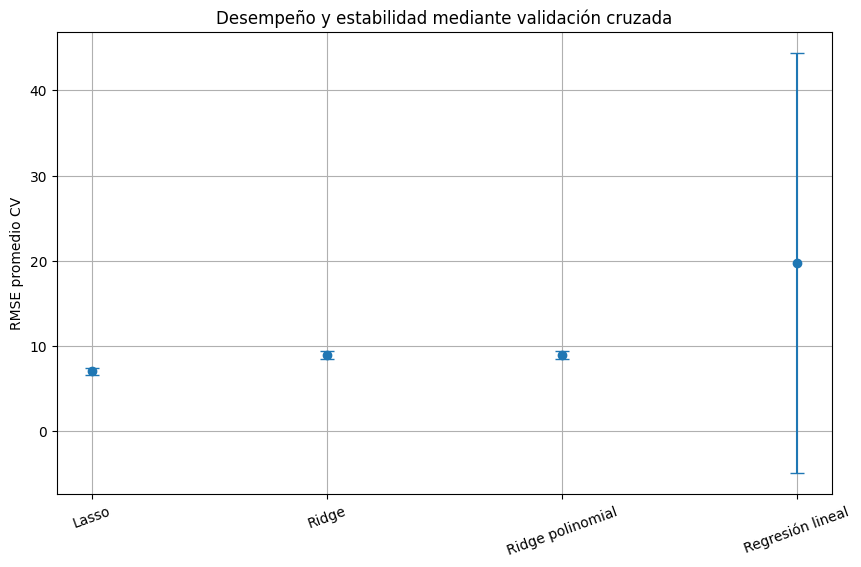

In [16]:
plt.figure(figsize=(10, 6))
x = np.arange(len(comparacion_final))
plt.errorbar(
    x,
    comparacion_final['RMSE_CV'],
    yerr=comparacion_final['Std_RMSE_CV'],
    fmt='o',
    capsize=5
)
plt.xticks(x, comparacion_final['Modelo'], rotation=20)
plt.ylabel('RMSE promedio CV')
plt.title('Desempeño y estabilidad mediante validación cruzada')
plt.grid(True)
plt.show()

# 7. Intervalos de confianza mediante bootstrap

El modelo seleccionado se mantiene fijo. Sobre el conjunto de test se remuestrean observaciones con reemplazo 1000 veces y se recalculan RMSE, MAE y R². Los intervalos se obtienen mediante los percentiles 2.5 y 97.5 de las distribuciones bootstrap.

In [17]:
y_test_pred = modelo_seleccionado.predict(X_test)

n_bootstrap = 1000
rng = np.random.default_rng(RANDOM_STATE)
rmse_bootstrap = np.empty(n_bootstrap)
mae_bootstrap = np.empty(n_bootstrap)
r2_bootstrap = np.empty(n_bootstrap)

n_test = len(y_test)

for i in range(n_bootstrap):
    idx = rng.integers(0, n_test, size=n_test)
    y_real = y_test.iloc[idx].to_numpy()
    y_pred = y_test_pred[idx]

    rmse_bootstrap[i] = np.sqrt(mean_squared_error(y_real, y_pred))
    mae_bootstrap[i] = mean_absolute_error(y_real, y_pred)
    r2_bootstrap[i] = r2_score(y_real, y_pred)

ic_rmse = np.percentile(rmse_bootstrap, [2.5, 97.5])
ic_mae = np.percentile(mae_bootstrap, [2.5, 97.5])
ic_r2 = np.percentile(r2_bootstrap, [2.5, 97.5])

resultados_bootstrap = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²'],
    'Estimación test': [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred),
        r2_score(y_test, y_test_pred)
    ],
    'IC 95% inferior': [ic_rmse[0], ic_mae[0], ic_r2[0]],
    'IC 95% superior': [ic_rmse[1], ic_mae[1], ic_r2[1]]
})

resultados_bootstrap

,Métrica,Estimación test,IC 95% inferior,IC 95% superior
0,RMSE,6.995999,6.457254,7.576006
1,MAE,5.441561,5.075324,5.857287
2,R²,0.428489,0.367244,0.484861


El modelo seleccionado mediante validación cruzada se mantiene fijo y se evalúa sobre el conjunto de test reservado previamente. Para cuantificar la incertidumbre de las métricas, se realizan 1000 remuestreos con reemplazo del conjunto de test.

En cada remuestreo se recalculan RMSE, MAE y R². Los intervalos de confianza del 95% se obtienen mediante los percentiles 2.5 y 97.5 de cada distribución Bootstrap.

El modelo obtiene en test un RMSE de 6.9960, un MAE de 5.4416 y un R² de 0.4285. Los intervalos de confianza son:
- RMSE: [6.4573, 7.5760]
- MAE: [5.0753, 5.8573]
- R²: [0.3672, 0.4849]

Los intervalos permiten cuantificar la incertidumbre asociada a las métricas y evaluar qué tan sensibles son a cambios en la composición de la muestra evaluada.

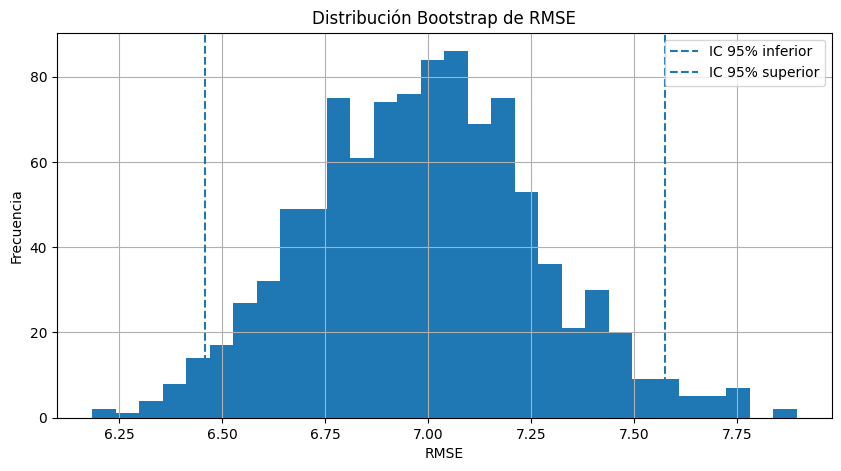

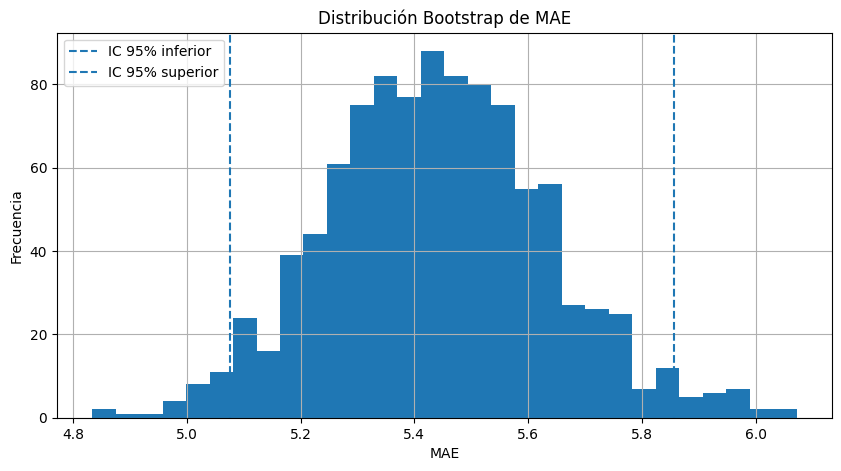

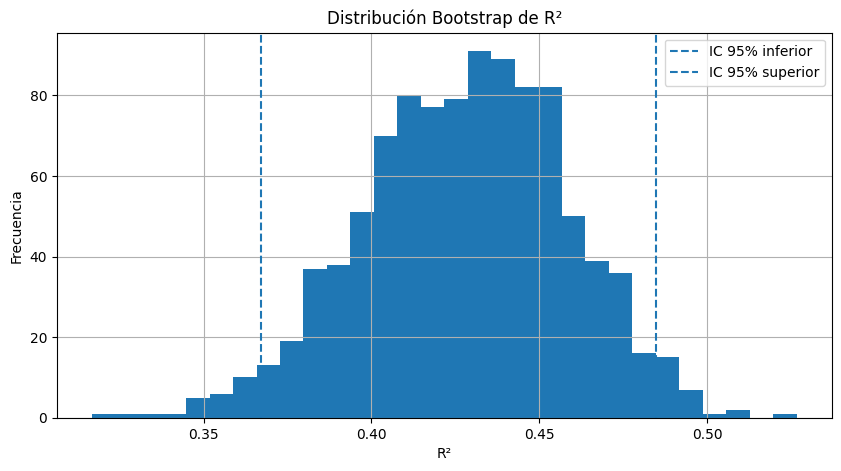

In [18]:
figuras = [
    ('RMSE', rmse_bootstrap, ic_rmse),
    ('MAE', mae_bootstrap, ic_mae),
    ('R²', r2_bootstrap, ic_r2)
]

for nombre, valores, intervalo in figuras:
    plt.figure(figsize=(10, 5))
    plt.hist(valores, bins=30)
    plt.axvline(intervalo[0], linestyle='--', label='IC 95% inferior')
    plt.axvline(intervalo[1], linestyle='--', label='IC 95% superior')
    plt.xlabel(nombre)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución Bootstrap de {nombre}')
    plt.legend()
    plt.grid(True)
    plt.show()

# 8. Análisis de resultados

### Análisis cuantitativo

1. **¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
El menor RMSE en el conjunto de test fue obtenido por Regresión lineal, con RMSE = 6.7903, MAE = 5.1995 y R² = 0.4616.

2. **¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?**
El modelo seleccionado mediante validación cruzada fue Lasso, con RMSE CV = 7.0487 y desviación estándar = 0.4361. El mejor RMSE de test corresponde a Regresión lineal. Por tanto, no coinciden. Esta diferencia es esperable porque la validación cruzada y el test evalúan muestras distintas; una diferencia moderada puede deberse a variabilidad muestral.

3. **¿El modelo con mejor métrica promedio es necesariamente el más adecuado?**
No. El promedio de RMSE debe interpretarse junto con su desviación estándar. Un modelo con RMSE ligeramente menor pero alta variabilidad puede ser menos confiable que otro con desempeño muy cercano y menor desviación. En esta comparación, el modelo seleccionado presenta RMSE CV = 7.0487 y desviación estándar = 0.4361.

4. **¿Cómo cambia el error con la complejidad y dónde se evidencia sobreajuste?**
Al aumentar el grado, el error de entrenamiento debe disminuir porque el modelo tiene mayor capacidad de ajuste. El sobreajuste se identifica cuando el RMSE de validación deja de mejorar y comienza a aumentar mientras el RMSE de entrenamiento continúa bajando. En esta ejecución, el mínimo de la curva de validación se encuentra en grado 1 y el aumento posterior comienza en grado 2.

5. **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
Ridge penaliza el cuadrado de los coeficientes y tiende a reducir sus magnitudes sin imponer ceros exactos; Lasso penaliza su valor absoluto y puede producir soluciones esparsas. En la solución Lasso, 128 de 144 coeficientes quedaron en cero, equivalente a 88.9% de las características generadas. La tabla de estabilidad de coeficientes permite además observar cuánto cambian los parámetros entre los folds.

6. **¿Los intervalos de confianza sugieren estabilidad o alta variabilidad?**
Los intervalos bootstrap obtenidos con 1000 remuestreos son: RMSE [6.4573, 7.5760], MAE [5.0753, 5.8573] y R² [0.3672, 0.4849]. Su amplitud permite valorar la variabilidad de cada métrica. Intervalos más estrechos indican mayor estabilidad de la métrica frente a cambios en la composición del test, mientras que intervalos amplios indican mayor incertidumbre.

### Análisis cualitativo

7. **¿Qué variables fueron seleccionadas como más relevantes por Lasso?**
Las características con mayor magnitud absoluta de coeficiente en esta ejecución son: num__humedad_desv (21.6127), num__dia_del_anio (4.9656), cat__mes_July (3.4361), num__humedad_max (-2.7714), cat__mes_December (-2.3189). Además, Lasso llevó 128 coeficientes a cero, por lo que su selección debe interpretarse como selección automática dentro del conjunto y escala utilizados.

8. **¿Qué interpretación práctica tienen los coeficientes del modelo final?**
Los coeficientes numéricos corresponden al efecto asociado a una unidad de la variable después del escalamiento incluido en el pipeline. Un signo positivo indica una asociación con una predicción mayor de temperatura, mientras que un signo negativo indica una asociación con una predicción menor, manteniendo las demás características constantes. Las variables categóricas deben interpretarse como efectos de sus indicadores One-Hot y no como diferencias frente a una única referencia, porque no se eliminó una categoría.

9. **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**
Sí. La precisión se mide principalmente con RMSE, MAE y R², mientras que la interpretabilidad depende de la cantidad y estructura de las características y de la magnitud de los coeficientes. Un modelo polinomial puede introducir muchas interacciones y términos, mientras que Lasso puede reducir la complejidad efectiva al llevar coeficientes a cero. Por ello, la elección debe considerar tanto desempeño como facilidad de explicación.

10. **¿Qué decisiones estratégicas podría tomar AlpesPlanck?**
AlpesPlanck podría usar el modelo seleccionado como apoyo para anticipar temperaturas máximas y planear actividades o recursos sensibles a las condiciones meteorológicas. Las variables retenidas por Lasso pueden servir para priorizar monitoreo y análisis. Antes de una implementación operativa, conviene evaluar el modelo con datos nuevos y establecer un seguimiento periódico de sus métricas.

11. **¿Mayor precisión implica necesariamente mayor valor para la organización?**
No. Una mejora predictiva solo genera valor si cambia una decisión de manera beneficiosa y a un costo razonable. También importan estabilidad, interpretabilidad, mantenimiento y disponibilidad de las variables en el momento de predicción.

12. **¿Un modelo más complejo necesariamente genera mayor valor empresarial?**
No. La complejidad aumenta la capacidad de representar patrones, pero también puede aumentar la varianza, el costo de implementación y la dificultad de explicar el resultado. En este ejercicio, el comportamiento de la curva de validación debe utilizarse para justificar cuándo la complejidad deja de aportar generalización.

### Reflexión conceptual

13. **¿Qué relación existe entre complejidad, generalización y estabilidad?**
La complejidad aumenta la capacidad de ajuste. Cuando el grado aumenta demasiado, el modelo puede capturar particularidades de entrenamiento que no se repiten en otras muestras; entonces el error de validación aumenta y la variabilidad entre folds suele crecer. La regularización actúa limitando la magnitud de los coeficientes y, por tanto, la complejidad efectiva.

14. **¿Qué fuentes de sesgo podrían estar presentes?**
El sesgo puede provenir de la representatividad de las observaciones meteorológicas, errores de medición, datos faltantes, cobertura desigual por temporada o estación y decisiones de modelado como exclusión de variables o forma funcional asumida. La partición aleatoria utilizada aquí también debe considerarse una decisión metodológica: si existe una dependencia temporal fuerte, una evaluación temporal podría ser más exigente que una partición aleatoria.

15. **¿Qué ocurriría con un tamaño de muestra mayor?**
En general, una muestra mayor proporciona más información para estimar los parámetros y hace que cada fold de validación represente mejor la distribución de datos, por lo que se espera menor variabilidad de las métricas y de los coeficientes. No obstante, aumentar el tamaño no elimina sesgos sistemáticos ni errores de medición presentes en los datos.

# 9. Uso de herramientas de IA generativa

**Herramienta utilizada:** ChatGPT (OpenAI).

**Objetivo de uso:**
- Apoyo metodológico para estructurar el análisis de complejidad y la búsqueda de hiperparámetros.
- Asistencia en la redacción y depuración de fragmentos de código en Python.
- Orientación para interpretar métricas de desempeño y comparar configuraciones de modelo.

**Alcance y tipo de asistencia:**
- Se utilizó la IAG como soporte técnico y conceptual, no como sustituto del criterio del equipo.
- Todas las recomendaciones fueron revisadas, adaptadas y validadas con evidencia experimental.

**Consultas representativas:**
- "¿Qué estrategia de validación es adecuada para comparar configuraciones de hiperparámetros?"
- "¿Cómo interpretar variaciones en métricas entre entrenamiento y validación?"
- "¿Qué señales sugieren sobreajuste en procesos de ajuste de hiperparámetros?"

**Evaluación crítica del apoyo recibido:**
- La IAG aceleró la implementación inicial, pero requirió ajustes para alinearse con la estructura del dataset y los objetivos del laboratorio.
- Algunas propuestas mejoraron claridad y organización del código; otras no aportaron mejora empírica y fueron descartadas.
- La decisión final sobre modelo y parámetros se basó en resultados reproducibles y no en sugerencias automáticas.

**Aportes del equipo:**
- Definición del protocolo experimental, particiones y métricas de comparación.
- Diseño y ejecución de experimentos de hiperparámetros, con registro de resultados.
- Verificación de consistencia entre preprocesamiento, entrenamiento y evaluación.
- Selección del modelo final con base en desempeño, estabilidad y capacidad de generalización.
- Se redactó el análisis cuantitativo y cualitativo basandonos en los resultados obtenidos 